<a href="https://colab.research.google.com/github/sagasucksatlife1/QuantProjects/blob/main/InterestRatesModeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INTEREST RATE MODELING

Interst rate modeling is used to evaluate the interest rates, to price the dervatives,  An interest-rate model is just a probabilistic recipe describing how rates can move over time.



So to start this creating this model, we import the past insterst rates of us treasuries, over differnet maturities, 1 month to 30 years.

We download all of those in csv formats and marge based on dates. to create a final master csv contains dates and all different interest rates at for bonds with differnt maturities.

btw pls forgive me for the spelling errors throughout the doc as i have written it by hand and typing them as quick as posssible....

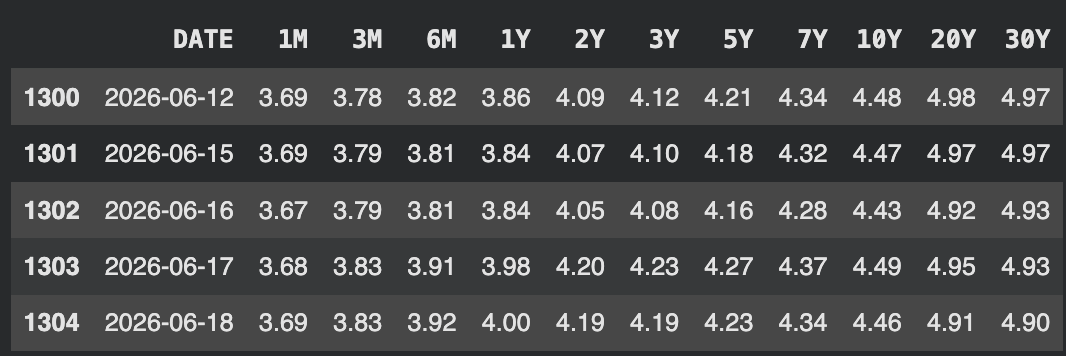

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


d1 = pd.read_csv("/content/DGS1MO.csv")
d2 = pd.read_csv("/content/DGS3MO.csv")
d3 = pd.read_csv("/content/DGS6MO.csv")
d4 = pd.read_csv("/content/DGS1.csv")
d5 = pd.read_csv("/content/DGS2.csv")
d6 = pd.read_csv("/content/DGS3.csv")
d7 = pd.read_csv("/content/DGS5.csv")
d8 = pd.read_csv("/content/DGS7.csv")
d9 = pd.read_csv("/content/DGS10.csv")
d10 = pd.read_csv("/content/DGS20.csv")
d11 = pd.read_csv("/content/DGS30.csv")


d1.columns = ["DATE", "1M"]
d2.columns = ["DATE", "3M"]
d3.columns = ["DATE", "6M"]
d4.columns = ["DATE", "1Y"]
d5.columns = ["DATE", "2Y"]
d6.columns = ["DATE", "3Y"]
d7.columns = ["DATE", "5Y"]
d8.columns = ["DATE", "7Y"]
d9.columns = ["DATE", "10Y"]
d10.columns = ["DATE", "20Y"]
d11.columns = ["DATE", "30Y"]



master = d1.merge(d2, on="DATE")
master = master.merge(d3, on="DATE")
master = master.merge(d4, on="DATE")
master = master.merge(d5, on="DATE")
master = master.merge(d6, on="DATE")
master = master.merge(d7, on="DATE")
master = master.merge(d8, on="DATE")
master = master.merge(d9, on="DATE")
master = master.merge(d10, on="DATE")
master = master.merge(d11, on="DATE")


master.head()
master.tail()


,DATE,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
1300,2026-06-12,3.69,3.78,3.82,3.86,4.09,4.12,4.21,4.34,4.48,4.98,4.97
1301,2026-06-15,3.69,3.79,3.81,3.84,4.07,4.10,4.18,4.32,4.47,4.97,4.97
1302,2026-06-16,3.67,3.79,3.81,3.84,4.05,4.08,4.16,4.28,4.43,4.92,4.93
1303,2026-06-17,3.68,3.83,3.91,3.98,4.20,4.23,4.27,4.37,4.49,4.95,4.93
1304,2026-06-18,3.69,3.83,3.92,4.00,4.19,4.19,4.23,4.34,4.46,4.91,4.90


Now as all these are just rates and we need to determine the price of bonds based on these rates, thus we convert the rates into yeilds by dividing them by 100.

then we create a seprate array for the matruities in numeric format.

at last we use the yeilds and maturity to convert rates into discont-factors because of the simple reason that pricing bond cannot be done through rates we need discount factor for that.

the following is the formula for detrmining the df from K= yeild and
t = maturties

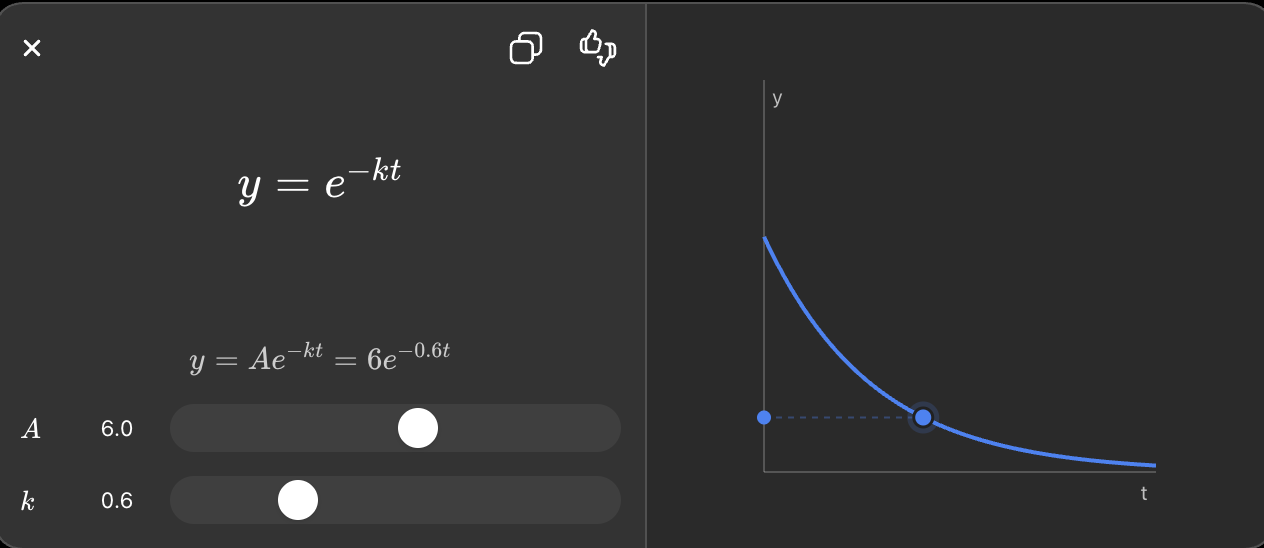




In [3]:
latest_curve = master.iloc[-1]
print(latest_curve)
yields = latest_curve.iloc[1:].astype(float).values
yields = yields / 100
print(yields)

maturities = [1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30]
matuirites = np.array(maturities)

discount_factors = np.exp(-yields* matuirites)
print(discount_factors)

discount_curve = pd.DataFrame({"Matutities": maturities,"Yeilds": yields,"Discount Factors": discount_factors})
print(discount_curve)

discount_curve.to_csv(
    "market_discount_curve.csv",
    index=False
)

DATE    2026-06-18
1M            3.69
3M            3.83
6M            3.92
1Y             4.0
2Y            4.19
3Y            4.19
5Y            4.23
7Y            4.34
10Y           4.46
20Y           4.91
30Y            4.9
Name: 1304, dtype: object
[0.0369 0.0383 0.0392 0.04   0.0419 0.0419 0.0423 0.0434 0.0446 0.0491
 0.049 ]
[0.99692972 0.99047069 0.98059083 0.96078944 0.91961516 0.88187937
 0.80936928 0.73800845 0.64018377 0.37456123 0.22992549]
    Matutities  Yeilds  Discount Factors
0     0.083333  0.0369          0.996930
1     0.250000  0.0383          0.990471
2     0.500000  0.0392          0.980591
3     1.000000  0.0400          0.960789
4     2.000000  0.0419          0.919615
5     3.000000  0.0419          0.881879
6     5.000000  0.0423          0.809369
7     7.000000  0.0434          0.738008
8    10.000000  0.0446          0.640184
9    20.000000  0.0491          0.374561
10   30.000000  0.0490          0.229925


The below figure is a yeild curve which is the bottom one, which is upward sloping, meaning that higher maturites lead to higher yeild.

The top graph is the discount factor graph of the us treasuries which shows that as maturties inc. the discounting factor falls.

Indirectly telling us that higher yeilds lead to lower discounting factor and lower yeild lead to higher discounting factor.... which make total scence when u try to understand that df is nothing but the vlue of 1 dollar revived in the future is worth today.


If the intrest rates are high the yeilds are high the inflation is low thus the value of money is going to be higher.... leading to smalller discount factor

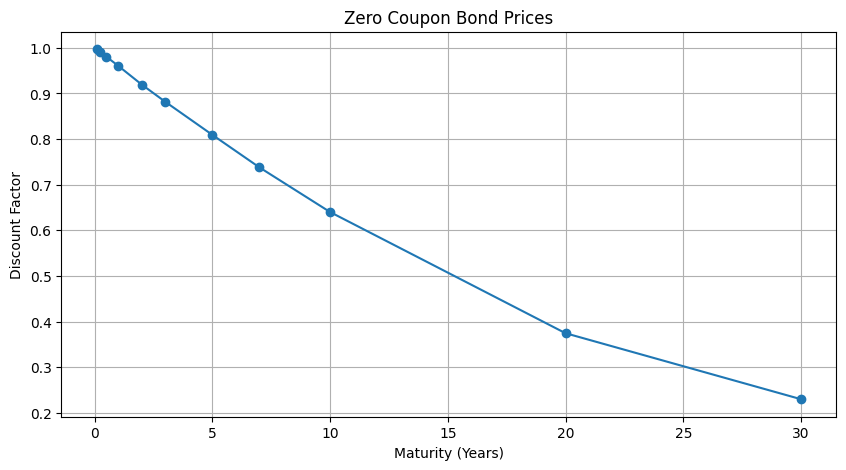

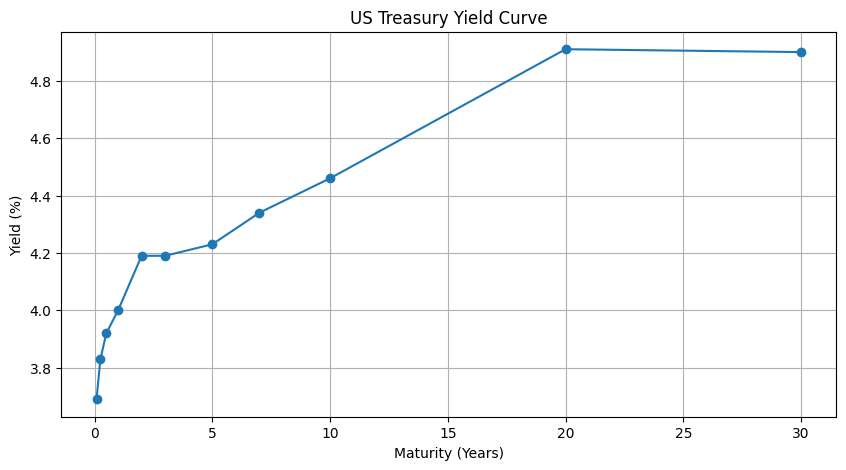

In [4]:
plt.figure(figsize=(10,5))
plt.plot(maturities, discount_factors, marker="o")
plt.xlabel("Maturity (Years)")
plt.ylabel("Discount Factor")
plt.title("Zero Coupon Bond Prices")
plt.grid(True)
plt.show()


plt.figure(figsize=(10,5))
plt.plot(maturities, yields * 100, marker="o")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("US Treasury Yield Curve")
plt.grid(True)
plt.show()

now we use vasicek model to estimates the intrest rate over the past years..

this is a short term intrest rate:
dr = Adt + (sigma)dw

now we see that both alpha and sigma are not random, but dependent on the rates.

from ito lemma:
dr = A(r,t)dt + simga(r,t)dt

now intrest rates are not random, they trend to revert back towards the mean, mean reversion.

A(r,t) = kappa * (r - R).  *kappa = acceleratipn to mean*

Now we also dissect the second term of this equation. Here, the model depends on how the rates are dependent on the volatility.

If the rates are independent of the volatility, then that is a simple vasicek model.

If the rates are the square root of the current volatility, then it is a CIR model.

And last but not the least, if the rates are directly dependent on the volatility, that means that is a Dothan model.


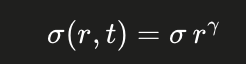



In the below example, we are using theta, which is the reversion to be 0.04, the acceleration coefficient to be 0.6, and the volatility to be 0.015. We iterate this and run a loop where each forward rate is dependent on the past rate. And we determined the rate using the normal equation, the vasicek equation, dr = (kappa*(theta - rates[i])* dt + sigma* np.sqrt(dt)* Z).

We run this over a loop and finally plot a final vasicek interest rate simulation graph for the past ten years.

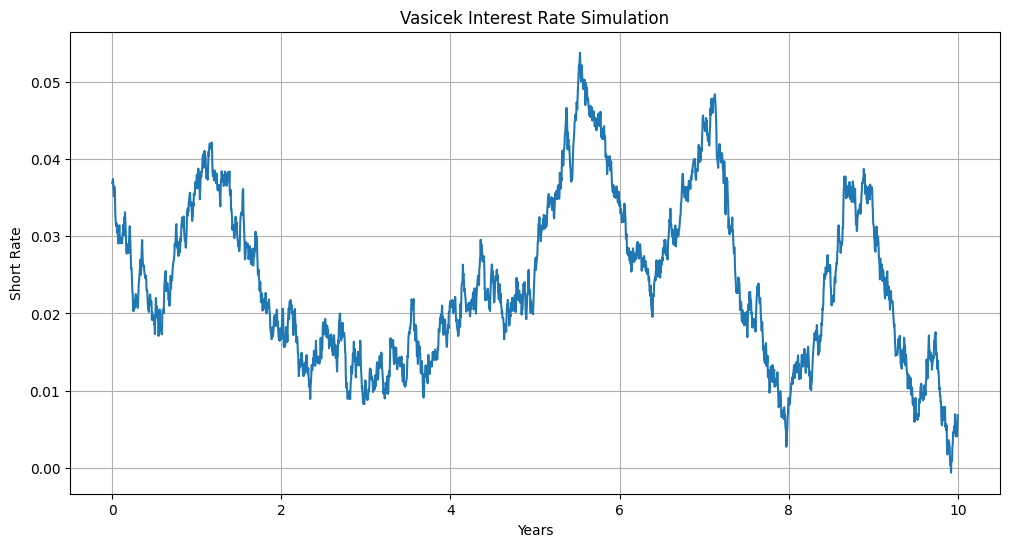

In [5]:

r = yields[0]
theta = 0.04
kappa = 0.6
sigma = 0.015
T= 10
steps = 2520
dt = T/steps

rates = np.zeros(steps+1)
rates[0]=r

for i in range(steps):
  Z = np.random.normal(0,1)
  dr = (kappa*(theta - rates[i])* dt + sigma* np.sqrt(dt)* Z)
  rates[i + 1] = rates[i] + dr

time = np.linspace(0, T, steps + 1)
plt.figure(figsize=(12,6))
plt.plot(time, rates)
plt.title("Vasicek Interest Rate Simulation")
plt.xlabel("Years")
plt.ylabel("Short Rate")
plt.grid(True)
plt.show()



Now that we have a rough estiamtion of the movement of intrest rates over the interval of the last ten years we use monte carlo startegy to predict the most probablistic path of the interest rates. we do tgis by running 2 nested for loops the inner loop runs same as the above 2520 points joined toghter to form one path.... the only csthch is the oter loop which runs a 100 times, and plots 100 such paths randomly where the intrest rates could go.

the in the last we calculate the mean of those paths to find the most appropriate path and plot it on a figure.

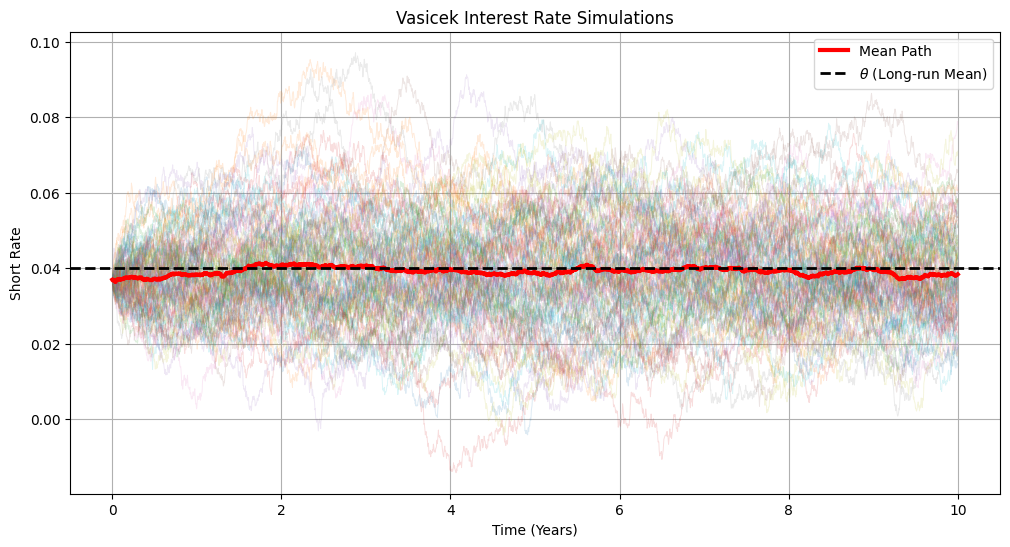

In [6]:
num_paths = 100

all_paths = np.zeros((num_paths, steps + 1))
for p in range(num_paths):
    all_paths[p,0] = r
    for i in range(steps):
        Z = np.random.normal()
        dr = (kappa*(theta-all_paths[p,i])*dt+ sigma*np.sqrt(dt)*Z)

        all_paths[p,i+1] = all_paths[p,i] + dr

plt.figure(figsize=(12,6))

# Plot all simulated paths
for p in range(num_paths):
    plt.plot(time, all_paths[p], alpha=0.15, linewidth=0.7)

# Mean path
mean_path = np.mean(all_paths, axis=0)

plt.plot(
    time,
    mean_path,
    color="red",
    linewidth=3,
    label="Mean Path"
)

# Long-run mean (theta)
plt.axhline(
    y=theta,
    color="black",
    linestyle="--",
    linewidth=2,
    label=r"$\theta$ (Long-run Mean)"
)

plt.title("Vasicek Interest Rate Simulations")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.legend()
plt.grid(True)

plt.show()

Here we do the same thing the only catch is instead of running 100 random paths we run it across 10,000 random paths and see the law of large nos. as play where the mean is almost coinciding with the actual mean.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


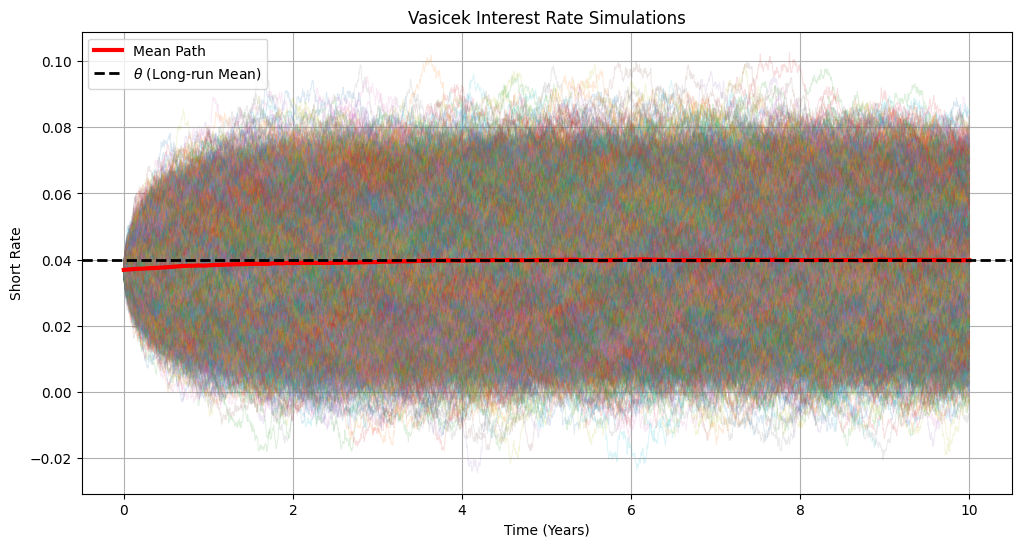

In [7]:
num_paths = 10000
all_paths = np.zeros((num_paths, steps + 1))
for p in range(num_paths):
    all_paths[p,0] = r
    for i in range(steps):
        Z = np.random.normal()
        dr = (kappa*(theta-all_paths[p,i])*dt+ sigma*np.sqrt(dt)*Z)
        all_paths[p,i+1] = all_paths[p,i] + dr

plt.figure(figsize=(12,6))

# Plot all simulated paths
for p in range(num_paths):
    plt.plot(time, all_paths[p], alpha=0.15, linewidth=0.7)

# Mean path
mean_path = np.mean(all_paths, axis=0)

plt.plot(
    time,
    mean_path,
    color="red",
    linewidth=3,
    label="Mean Path"
)

# Long-run mean (theta)
plt.axhline(
    y=theta,
    color="black",
    linestyle="--",
    linewidth=2,
    label=r"$\theta$ (Long-run Mean)"
)

plt.title("Vasicek Interest Rate Simulations")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.legend()
plt.grid(True)

plt.show()

now again as we have done before the mean intrest rates are just pure rates, they are no prices we can work with so we convert them in discount factor, we. create an empty discount array and calculate all discounts in there, the final price using the df using the vasicek model is the mean of this array, which is the monte carlo bond price: 0.6757479173879548

In [8]:
path = all_paths[0]
discount_factor = []

for path in all_paths:
  discount = np.exp(-np.sum(path * dt))
  discount_factor.append(discount)

mc_price = np.mean(discount_factor)
print("Monte Carlo Bond Price:", mc_price)

Monte Carlo Bond Price: 0.6755534424400993


now we create a function called vasicek_bond_price, we specify the same values of varibvle as we did in the monte carlo pricing method to calculate the interest rates, now we use the vasicek formula for the closed-form price of a zero-coupon bond which is:
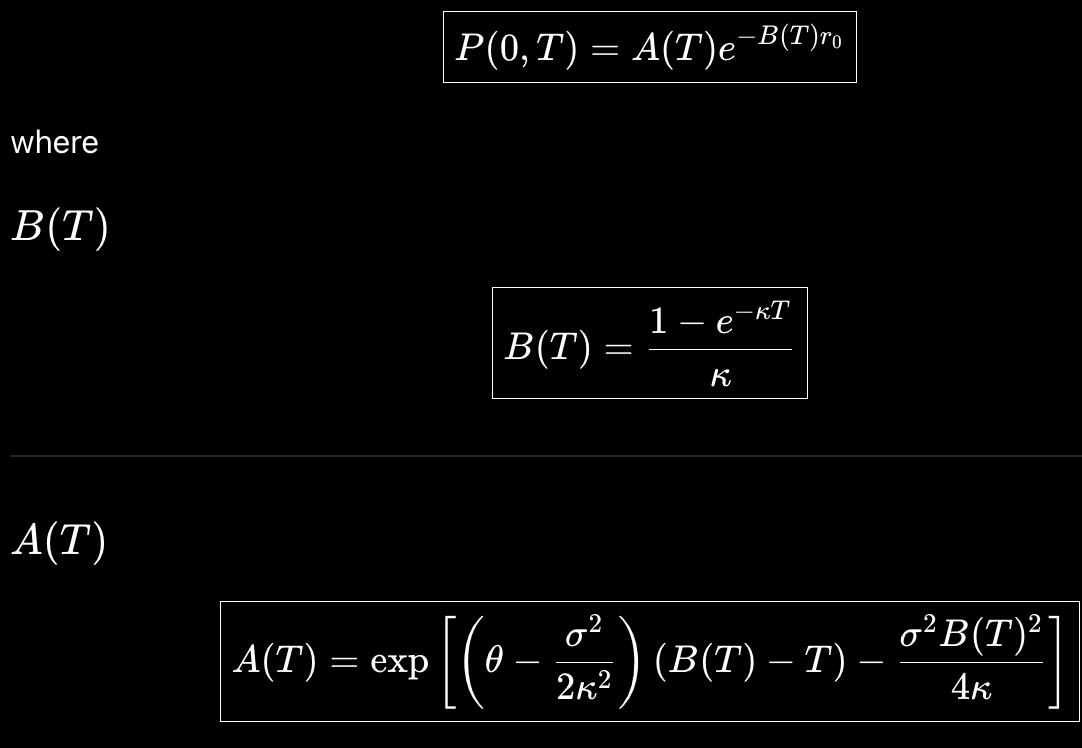

In [9]:
def vasicek_bond_price(r0, kappa, theta, sigma, T):
 B = (1 - np.exp(-kappa * T)) / kappa
 A = np.exp((theta- sigma**2 / (2 * kappa**2)) * (B - T)-(sigma**2 * B**2) / (4 * kappa))
 return A * np.exp(-B * r0)


vasicek_price =  vasicek_bond_price(r, kappa, theta, sigma, 10)

comparing the two pricing models we see that
Monte Carlo : 0.6757479173879548
Closed Form : 0.6753664748166517
Difference  : 0.00038144257130312553

In [10]:
print("Monte Carlo :", mc_price)
print("Closed Form :", vasicek_price)
print("Difference  :", abs(mc_price - vasicek_price))

Monte Carlo : 0.6755534424400993
Closed Form : 0.6753664748166517
Difference  : 0.0001869676234476092


In [11]:
market_prices = discount_curve["Discount Factors"].values
maturities = discount_curve["Matutities"].values
print(market_prices)


[0.99692972 0.99047069 0.98059083 0.96078944 0.91961516 0.88187937
 0.80936928 0.73800845 0.64018377 0.37456123 0.22992549]


this is the calibrarion part, we dont need it specifically for the implementation of the but since we are using estimated value of kappa, sigma and theta.... we can always use differnce as the calibrater and reduce it using the minimise function and find out the value of kappa , theta and sigma that best represnt the reduced price differnce.

In [12]:
from scipy.optimize import minimize
def objective(params):
  kappa, theta, sigma = params
  model_price = []
  for T in maturities:
    B = (1 - np.exp(-kappa*T))/kappa
    A = np.exp((theta- sigma**2/(2*kappa**2))*(B-T)-sigma**2*B**2/(4*kappa))
    P = A*np.exp(-B*r)
    model_price.append(P)
  return np.sum((model_price - market_prices)**2)

params = [0.6, 0.04, 0.015]
print(objective(params))

0.014113487932798301


we put the normal values that we were using to price as the starting guess, implementing the minization and obtaining the obtimal values of kappa and theta

Optimal kappa : 0.18481953132671278

Optimal theta : 0.05232869997417269

In [13]:
guess = [0.60, 0.04, 0.015]
result= minimize(objective, guess, method="L-BFGS-B", bounds=[(0.01,5),(0.0,0.20),(0.0001,0.10)])
kappa_opt, theta_opt, sigma_opt = result.x

print("Optimal kappa :", kappa_opt)
print("Optimal theta :", theta_opt)


Optimal kappa : 0.18481953132671278
Optimal theta : 0.05232869997417269


Now that we have the optimal values of the varibales, we dont need to guess anymore and directly put it in a closed zero bond pricing function and generate a calibrated curve.

In [14]:
kappa = kappa_opt
theta = theta_opt
sigma = 0.001

calibrated_model_prices = []
for T in maturities:
    B = (1 - np.exp(-kappa*T))/kappa
    A = np.exp((theta- sigma**2/(2*kappa**2))*(B-T)-sigma**2*B**2/(4*kappa))
    P = A*np.exp(-B*r)
    calibrated_model_prices.append(P)

calibrated_model_prices = np.array(calibrated_model_prices)
model_yields = -np.log(calibrated_model_prices) / maturities
model_yields = model_yields * 100
rmse = np.sqrt(np.mean((model_yields - yields*100)**2))
print(f"RMSE : {rmse:.6f}%")

comparison = pd.DataFrame({"Maturity": maturities,"Market Yield (%)": yields*100,"Model Yield (%)": model_yields,
"Market Bond Price": market_prices,"Model Bond Price": calibrated_model_prices})
print(comparison)


RMSE : 0.122375%
     Maturity  Market Yield (%)  Model Yield (%)  Market Bond Price  \
0    0.083333              3.69         3.701820           0.996930   
1    0.250000              3.83         3.725100           0.990471   
2    0.500000              3.92         3.759138           0.980591   
3    1.000000              4.00         3.824169           0.960789   
4    2.000000              4.19         3.942988           0.919615   
5    3.000000              4.19         4.048422           0.881879   
6    5.000000              4.23         4.225698           0.809369   
7    7.000000              4.34         4.367012           0.738008   
8   10.000000              4.46         4.529055           0.640184   
9   20.000000              4.91         4.824939           0.374561   
10  30.000000              4.90         4.954622           0.229925   

    Model Bond Price  
0           0.996920  
1           0.990730  
2           0.981380  
3           0.962480  
4           0.9

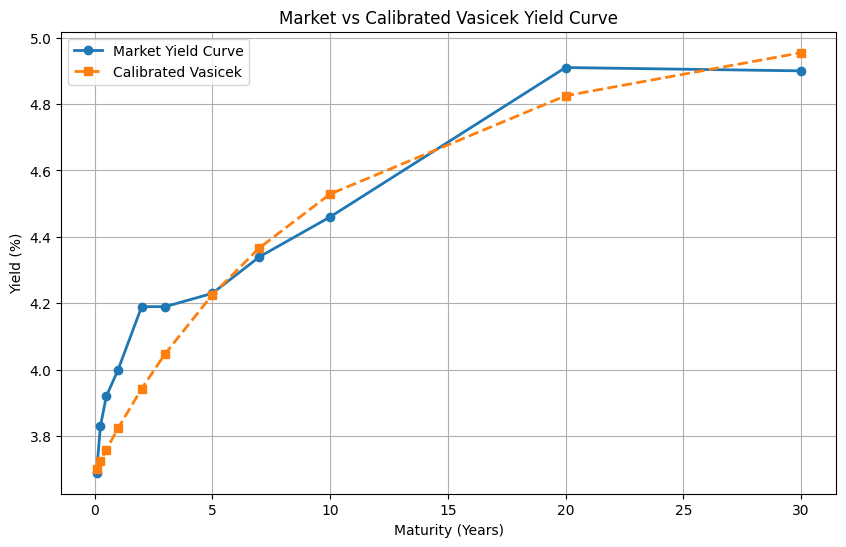

In [15]:
plt.figure(figsize=(10,6))

plt.plot(
    maturities,
    yields*100,
    marker='o',
    linewidth=2,
    label='Market Yield Curve'
)

plt.plot(
    maturities,
    model_yields,
    marker='s',
    linewidth=2,
    linestyle='--',
    label='Calibrated Vasicek'
)

plt.title("Market vs Calibrated Vasicek Yield Curve")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")

plt.grid(True)
plt.legend()

plt.show()

now we have compared the claibrated vasicek model, we see the overlap at higher maturtities, now we compare the that with the CIR interest rate model.

but first we evaluate the CIR intrset rate over the past 10 year tenure, as we did in the vasicek model.

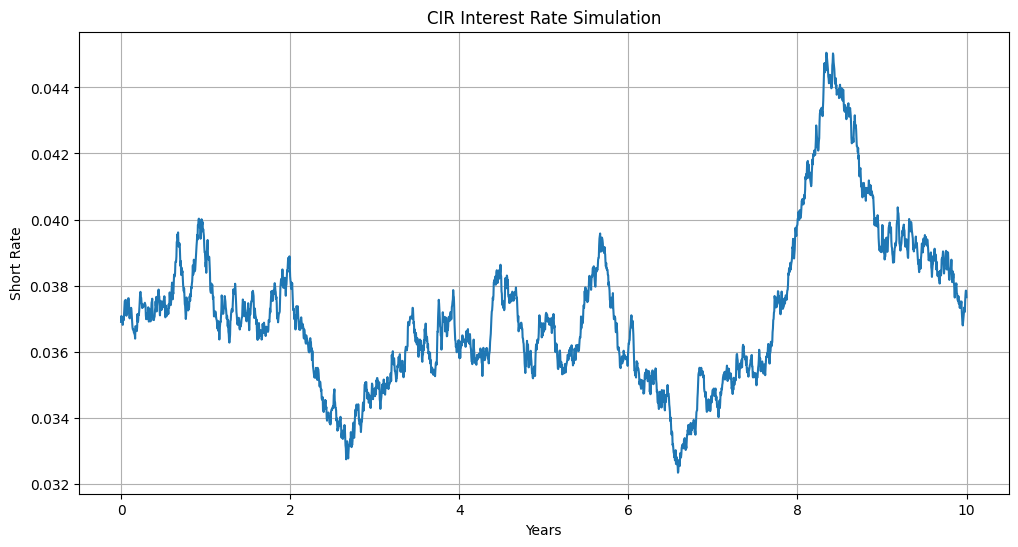

In [16]:
r0 = yields[0]
theta = 0.04
kappa = 0.6
sigma = 0.015
T= 10
steps = 2520
dt = T/steps

rates = np.zeros(steps + 1)
rates[0] = r0

for i in range(steps):

    Z = np.random.normal()
    r = max(rates[i], 0)

    dr = (kappa * (theta - r) * dt + sigma * np.sqrt(r) * np.sqrt(dt) * Z)
    rates[i+1] = max(r + dr, 0)


plt.figure(figsize=(12,6))
plt.plot(time, rates)
plt.title("CIR Interest Rate Simulation")
plt.xlabel("Years")
plt.ylabel("Short Rate")

plt.grid(True)

plt.show()

instead of running the monte carlo stimulation, he direclty jump into the pricing model, we we had already shown it in the above section.

cir bind priving function is the function where where we dont use the optimal value that we found through calibration but the normal values.

we get the prices as 0.6727887075885259

In [17]:
def cir_bond_price(r0, kappa, theta, sigma, T):

    gamma = np.sqrt(kappa**2 + 2*sigma**2)
    B = (2 * (np.exp(gamma*T) - 1)) / ((gamma + kappa) * (np.exp(gamma*T) - 1)+ 2* gamma)
    A = (( 2*gamma*np.exp((kappa+gamma)*T/2)) /((gamma+kappa)*(np.exp(gamma*T)-1)+ 2* gamma))**(2*kappa*theta/sigma**2)
    P = A*np.exp(-B*r0)

    return P

P = cir_bond_price(r, kappa, theta, sigma, 10)
print(P)

0.6727887075885259


in this part of the processs we again run minimse function, to recude the error btewwn the market price and the model price, and estimate the value of varibales accorndingly.

In [18]:
from scipy.optimize import minimize
def cir_objective(params):

    kappa, theta, sigma = params
    model_prices = []

    for T in maturities:

        P = cir_bond_price(r,kappa,theta,sigma,T)
        model_prices.append(P)

    model_prices = np.array(model_prices)

    error = np.sum((model_prices-market_prices)**2)
    return error

In [19]:
params = [0.6,0.04,0.015]
print(cir_objective(params))


0.012827435467216429


we put the normal values that we were using to price as the starting guess, implementing the minization and obtaining the obtimal values of kappa and theta

Kappa : 0.1562010542195115

Theta : 0.05277193041597709

In [23]:
guess_CIR = [0.60,
    0.04,
    0.015]

result = minimize( cir_objective,guess_CIR,method="L-BFGS-B",bounds=[(0.01,5), (0.0,0.20),(0.0001,0.10) ])
kappa_opt_CIR, theta_opt_CIR, sigma_opt_CIR = result.x

print("Optimal CIR Parameters")

print("Kappa :",kappa_opt_CIR)
print("Theta :",theta_opt_CIR)



Optimal CIR Parameters
Kappa : 0.1562010542195115
Theta : 0.05277193041597709


In [21]:
kappa = kappa_opt_CIR
theta = theta_opt_CIR
sigma = sigma_opt_CIR

calibrated_model_prices_CIR = []

for T in maturities:

    P = cir_bond_price(r,kappa,theta,sigma,T)
    calibrated_model_prices_CIR.append(P)

calibrated_model_prices_CIR = np.array(calibrated_model_prices_CIR)
model_yields_CIR = -np.log(calibrated_model_prices_CIR) / maturities
model_yields_CIR = model_yields_CIR * 100
rmse_CIR = np.sqrt(np.mean((model_yields_CIR - yields*100)**2))

print(f"RMSE : {rmse_CIR:.6f}%")
comparison_CIR = pd.DataFrame({
    "Maturity": maturities,
    "Market Yield (%)": yields*100,
    "CIR Yield (%)": model_yields_CIR,
    "Market Bond Price": market_prices,
    "CIR Bond Price": calibrated_model_prices_CIR})

print(comparison_CIR)

RMSE : 0.092368%
     Maturity  Market Yield (%)  CIR Yield (%)  Market Bond Price  \
0    0.083333              3.69       3.794139           0.996930   
1    0.250000              3.83       3.813236           0.990471   
2    0.500000              3.92       3.841268           0.980591   
3    1.000000              4.00       3.895202           0.960789   
4    2.000000              4.19       3.995112           0.919615   
5    3.000000              4.19       4.085381           0.881879   
6    5.000000              4.23       4.241063           0.809369   
7    7.000000              4.34       4.369253           0.738008   
8   10.000000              4.46       4.521677           0.640184   
9   20.000000              4.91       4.819815           0.374561   
10  30.000000              4.90       4.960839           0.229925   

    CIR Bond Price  
0         0.996843  
1         0.990512  
2         0.980977  
3         0.961797  
4         0.923207  
5         0.884652  
6      

Comparison

Market Curve (Blue): Represents the observed U.S. Treasury yield curve.
Calibrated Vasicek (Orange): Closely follows the market across most maturities and provides the best overall fit.
Calibrated CIR (Green): Also matches the market well but slightly overestimates short-term yields. It has the advantage of ensuring non-negative interest rates.

Conclusion: Both models fit the yield curve well, but Vasicek provides a slightly closer fit, while CIR is more realistic for modeling interest-rate dynamics because it prevents negative rates.

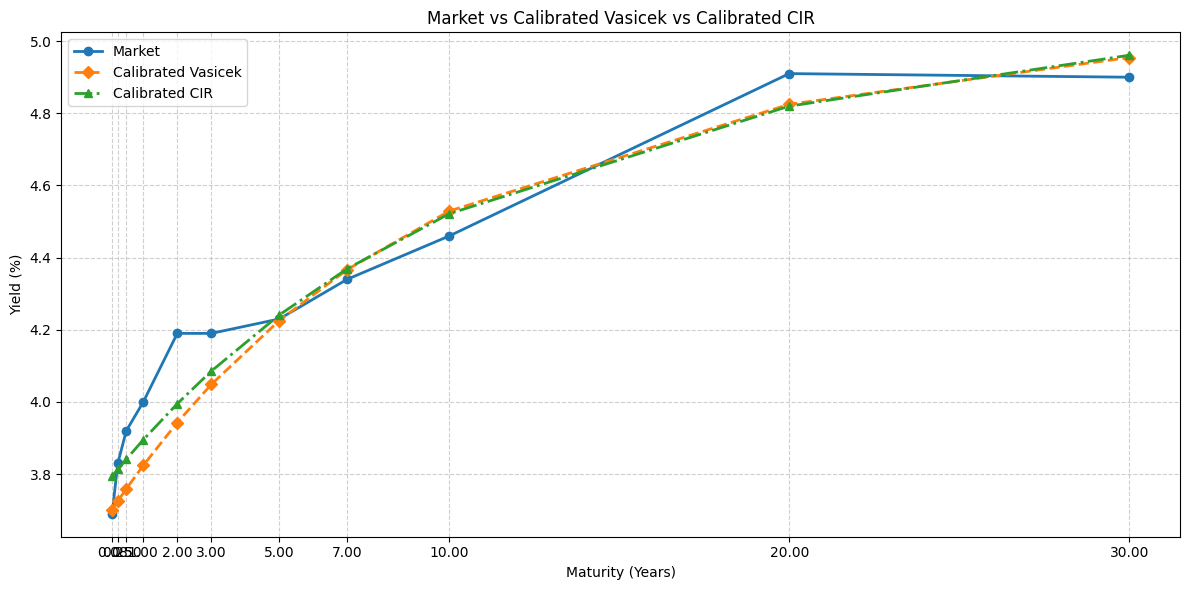

In [22]:
plt.figure(figsize=(12,6))

# Market Yield Curve
plt.plot(
    maturities,
    yields*100,
    marker='o',
    linewidth=2,
    label='Market'
)

# Calibrated Vasicek
plt.plot(
    maturities,
    model_yields,
    marker='D',
    linewidth=2,
    linestyle='--',
    label='Calibrated Vasicek'
)

# Calibrated CIR
plt.plot(
    maturities,
    model_yields_CIR,
    marker='^',
    linewidth=2,
    linestyle='-.',
    label='Calibrated CIR'
)

plt.title("Market vs Calibrated Vasicek vs Calibrated CIR")

plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")

plt.xticks(maturities)

plt.grid(True, linestyle='--', alpha=0.6)

plt.legend()

plt.tight_layout()

plt.show()